# Multi-Threshold EMG Trial Initiation Simulator

Runs repeated simulations across a sweep of initiation threshold window sizes.
Produces a curve of **window size (uV)** vs **number of trials**.

In [13]:
# Cell 1: Imports and constants
import numpy as np
import matplotlib.pyplot as plt
from open_ephys.analysis import Session

from helpers import (
    scan_experiment_structure,
    process_emg_signal,
    run_trial_initiation_simulation,
    PROTOCOL_ONLINE,
    SAMPLE_RATE_HINT,
    BIN_DURATION_MS,
)

DEFAULT_PROTOCOL = PROTOCOL_ONLINE
print('Imports loaded. Default protocol:', DEFAULT_PROTOCOL)

Imports loaded. Default protocol: Online Filtering


## 1. Load Session and Recording

In [14]:
# Cell 2: Session directory and record node
directory = "HR-08-Hour_Test_2026-03-26_08-16-26_001"

record_node_name  = "Record Node 106" if DEFAULT_PROTOCOL == PROTOCOL_ONLINE else "Record Node 111"
record_node_index = 0               if DEFAULT_PROTOCOL == PROTOCOL_ONLINE else 1

session   = Session(directory)
structure = scan_experiment_structure(directory, record_node_name)

flat_recordings = [
    (exp, rec)
    for exp, rec_list in structure.items()
    for rec in rec_list
]
print(f"Found {len(flat_recordings)} recording(s) across {len(structure)} experiment(s):")
for i, (e, r) in enumerate(flat_recordings):
    print(f"  [{i}] {e}/{r}")

Found 1 recording(s) across 1 experiment(s):
  [0] experiment1/recording1


In [15]:
# Cell 3: Load a specific recording (change RECORDING_INDEX to select another)
import os
RECORDING_INDEX = 0

recording = session.recordnodes[record_node_index].recordings[RECORDING_INDEX]

# Derive experiment/recording names from the recording directory path
parts         = recording.directory.split(os.sep)
recording_name   = parts[-1]
experiment_name  = parts[-2]
directory_str    = directory

# Load continuous stream
stream      = recording.continuous[0]
metadata    = stream.metadata
sample_rate = metadata.sample_rate
timestamps  = stream.timestamps
n_samples   = timestamps.shape[0]
data        = stream.get_samples(start_sample_index=0, end_sample_index=n_samples)

print(f"Loaded: {experiment_name}/{recording_name}")
print(f"Samples: {n_samples:,} | Duration: {timestamps[-1] - timestamps[0]:.1f} s | Rate: {sample_rate} Hz")
print(f"Channels: {metadata.num_channels} | Names: {metadata.channel_names}")

Loaded: experiment1/recording1
Samples: 13,789,220 | Duration: 2760.3 s | Rate: 5000.0 Hz
Channels: 5 | Names: ['CH1', 'CH5', 'CH7', 'CH8', 'ADC1']


## 2. Process EMG Signal

Using Online Filtering: assuming channel 3 is prefiltered differential EMG


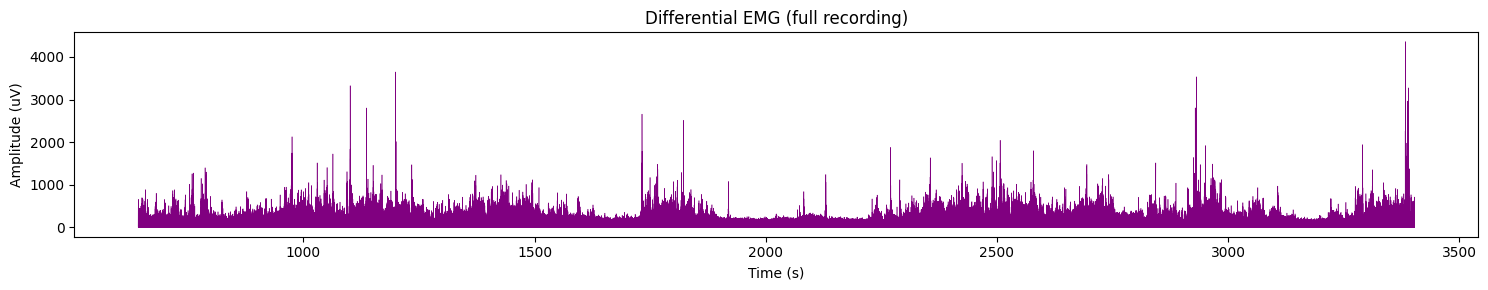

EMG processing complete.


In [16]:
# Cell 4: Compute differential filtered EMG
differential_filt, differential_emg = process_emg_signal(data, record_node_name, sample_rate)

plt.figure(figsize=(15, 3))
plt.plot(timestamps, differential_emg, color='purple', linewidth=0.4)
plt.title('Differential EMG (full recording)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (uV)')
plt.tight_layout()
plt.show()
print('EMG processing complete.')

## 3. Background EMG Distribution

Use this histogram to choose a sensible centre and range for the threshold sweep.

Bin mean distribution:  median=56.98 uV  std=33.11 uV  IQR=38.69 uV


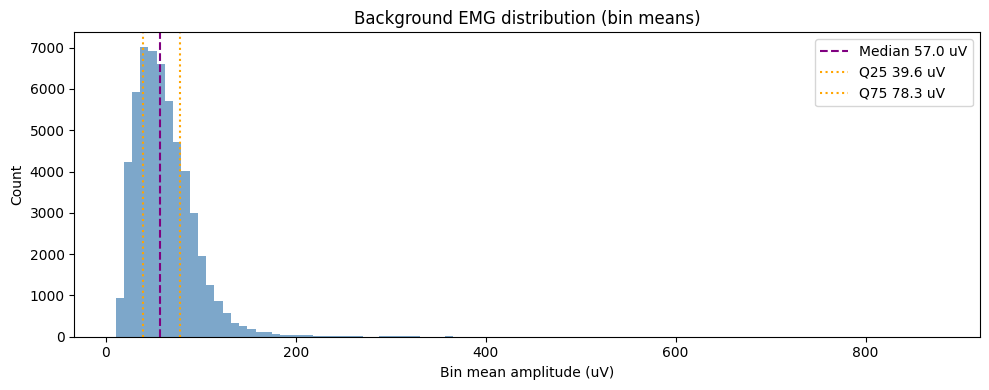

In [17]:
# Cell 5: Background distribution -- derive centre statistics
_bin_size  = int((sample_rate / 1000) * BIN_DURATION_MS)
_n_bins    = len(differential_emg) // _bin_size
_trimmed   = differential_emg[:_n_bins * _bin_size]
_bin_means = np.abs(_trimmed.reshape(_n_bins, _bin_size)).mean(axis=1)

_q25, _q50, _q75 = np.percentile(_bin_means, [25, 50, 75])
_std = _bin_means.std()
_iqr = _q75 - _q25

print(f'Bin mean distribution:  median={_q50:.2f} uV  std={_std:.2f} uV  IQR={_iqr:.2f} uV')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(_bin_means, bins=100, color='steelblue', alpha=0.7)
ax.axvline(_q50, color='purple', linestyle='--', label=f'Median {_q50:.1f} uV')
ax.axvline(_q25, color='orange', linestyle=':',  label=f'Q25 {_q25:.1f} uV')
ax.axvline(_q75, color='orange', linestyle=':',  label=f'Q75 {_q75:.1f} uV')
ax.set_xlabel('Bin mean amplitude (uV)')
ax.set_ylabel('Count')
ax.set_title('Background EMG distribution (bin means)')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Multi-Simulation Configuration

Define the threshold sweep here.

**Option A** -- provide explicit `(min_uV, max_uV)` pairs in `THRESHOLD_PAIRS`.  
**Option B** -- set `USE_AUTO_SWEEP = True` and specify a centre value plus a list of
half-widths; pairs are built automatically as `(centre - hw, centre + hw)`.

Only one option is active at a time (controlled by `USE_AUTO_SWEEP`).

In [18]:
# Cell 6: Threshold sweep configuration -- EDIT THIS CELL

# All windows are centred on the signal median (_q50).
# Pair = (median - half_width, median + half_width)

# -- Option A: explicit half-widths around the median --------------------
# Each value defines the +/- spread from the median. USE_AUTO_SWEEP must be False.
MANUAL_HALF_WIDTHS = [2, 5, 10, 15, 20, 30, 40, 50]

# -- Option B: automatic linspace of half-widths (default) ---------------
USE_AUTO_SWEEP    = True                      # set False to use MANUAL_HALF_WIDTHS
N_STEPS           = 20                        # number of window sizes to test
MIN_HALF_WIDTH    = 1.0                       # smallest half-width (uV)
MAX_HALF_WIDTH    = _std * 2                  # largest half-width (uV)

# -- Shared simulation parameters -----------------------------------------
VERBOSE_SIMS = False   # set True to print per-simulation progress

# -------------------------------------------------------------------------
# Build (min_uV, max_uV) pairs, all centred on the median
SWEEP_CENTRE = _q50   # median of background EMG bin distribution

half_widths = (
    np.linspace(MIN_HALF_WIDTH, MAX_HALF_WIDTH, N_STEPS)
    if USE_AUTO_SWEEP
    else np.array(MANUAL_HALF_WIDTHS, dtype=float)
)

THRESHOLD_PAIRS = [
    (float(SWEEP_CENTRE - hw), float(SWEEP_CENTRE + hw))
    for hw in half_widths
]

print(f"Sweep centre (median): {SWEEP_CENTRE:.2f} uV")
print(f"Number of simulations: {len(THRESHOLD_PAIRS)}")
print(f"Window sizes (uV): {[round(mx - mn, 2) for mn, mx in THRESHOLD_PAIRS]}")

Sweep centre (median): 56.98 uV
Number of simulations: 20
Window sizes (uV): [2.0, 8.87, 15.73, 22.6, 29.46, 36.33, 43.2, 50.06, 56.93, 63.8, 70.66, 77.53, 84.39, 91.26, 98.13, 104.99, 111.86, 118.73, 125.59, 132.46]


## 5. Run All Simulations

In [19]:
# Cell 7: Run the threshold sweep
TARGET_TRIALS = 150
recording_duration_s = float(timestamps[-1] - timestamps[0])
results = []

for i, (min_uv, max_uv) in enumerate(THRESHOLD_PAIRS):
    window_size = max_uv - min_uv
    print(f"[{i+1:>3}/{len(THRESHOLD_PAIRS)}]  min={min_uv:.2f}  max={max_uv:.2f}  window={window_size:.2f} uV  ... ", end="", flush=True)

    trials, stats_dict = run_trial_initiation_simulation(
        emg_signal=differential_emg,
        timestamps=timestamps,
        sample_rate=sample_rate,
        min_init_threshold=min_uv,
        max_init_threshold=max_uv,
        verbose=VERBOSE_SIMS,
    )

    n_total      = stats_dict["total_trials"]
    n_successful = stats_dict["successful_trials"]
    n_immediate  = stats_dict["immediate_success_trials"]

    # Time to reach TARGET_TRIALS: use actual timestamp if enough trials exist,
    # otherwise extrapolate linearly from the observed trial rate.
    if n_total >= TARGET_TRIALS:
        time_to_target_min = (trials[TARGET_TRIALS - 1].start_time - trials[0].start_time) / 60.0
    elif n_total > 0:
        rate_per_min = n_total / (recording_duration_s / 60.0)
        time_to_target_min = TARGET_TRIALS / rate_per_min
    else:
        time_to_target_min = float("nan")

    results.append({
        "min_uv":            min_uv,
        "max_uv":            max_uv,
        "window_size":       window_size,
        "n_trials":          n_total,
        "n_successful":      n_successful,
        "n_immediate":       n_immediate,
        "time_to_target_min": time_to_target_min,
        "stats":             stats_dict,
    })

    print(f"{n_total} trials  ({n_successful} successful, {n_immediate} immediate)  ~{time_to_target_min:.1f} min to {TARGET_TRIALS} trials")

print("All simulations complete.")


[  1/20]  min=55.98  max=57.98  window=2.00 uV  ... 97 trials  (97 successful, 6 immediate)  ~71.1 min to 150 trials
[  2/20]  min=52.54  max=61.41  window=8.87 uV  ... 106 trials  (106 successful, 20 immediate)  ~65.1 min to 150 trials
[  3/20]  min=49.11  max=64.84  window=15.73 uV  ... 124 trials  (124 successful, 40 immediate)  ~55.7 min to 150 trials
[  4/20]  min=45.68  max=68.27  window=22.60 uV  ... 141 trials  (141 successful, 65 immediate)  ~48.9 min to 150 trials
[  5/20]  min=42.24  max=71.71  window=29.46 uV  ... 160 trials  (160 successful, 78 immediate)  ~43.1 min to 150 trials
[  6/20]  min=38.81  max=75.14  window=36.33 uV  ... 171 trials  (171 successful, 100 immediate)  ~39.9 min to 150 trials
[  7/20]  min=35.38  max=78.57  window=43.20 uV  ... 185 trials  (185 successful, 124 immediate)  ~37.0 min to 150 trials
[  8/20]  min=31.94  max=82.01  window=50.06 uV  ... 188 trials  (188 successful, 135 immediate)  ~36.6 min to 150 trials
[  9/20]  min=28.51  max=85.44  wi

## 6. Plot: Initiation Window Size vs Number of Trials

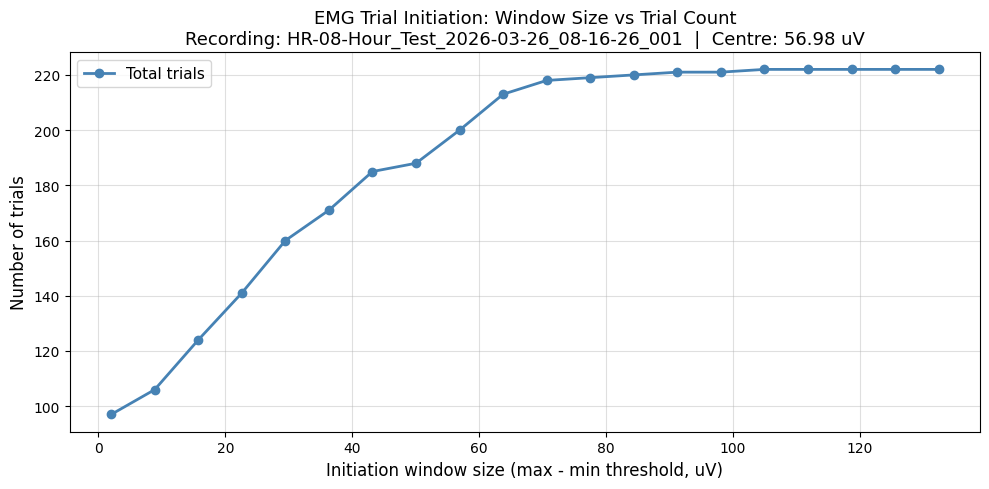

   Window (uV)    Min (uV)    Max (uV)     Total    Successful     Immediate
----------------------------------------------------------------------------
          2.00       55.98       57.98        97            97             6
          8.87       52.54       61.41       106           106            20
         15.73       49.11       64.84       124           124            40
         22.60       45.68       68.27       141           141            65
         29.46       42.24       71.71       160           160            78
         36.33       38.81       75.14       171           171           100
         43.20       35.38       78.57       185           185           124
         50.06       31.94       82.01       188           188           135
         56.93       28.51       85.44       200           200           155
         63.80       25.08       88.87       213           213           181
         70.66       21.64       92.31       218           218           194

In [20]:
# Cell 8: Window-size vs trial-count curve
window_sizes = [r["window_size"]  for r in results]
n_trials     = [r["n_trials"]     for r in results]
n_successful = [r["n_successful"] for r in results]
n_immediate  = [r["n_immediate"]  for r in results]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(window_sizes, n_trials,     "o-",  color="steelblue", linewidth=2, markersize=6, label="Total trials")
#ax.plot(window_sizes, n_successful, "s--", color="seagreen",  linewidth=2, markersize=6, label="Successful trials")
#ax.plot(window_sizes, n_immediate,  "^:",  color="darkorange", linewidth=2, markersize=6, label="Immediate (no shifting)")

ax.set_xlabel("Initiation window size (max - min threshold, uV)", fontsize=12)
ax.set_ylabel("Number of trials", fontsize=12)
ax.set_title(f"EMG Trial Initiation: Window Size vs Trial Count" + chr(10) + f"Recording: {directory_str}  |  Centre: {SWEEP_CENTRE:.2f} uV", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Summary table
col_w  = "Window (uV)"
col_mn = "Min (uV)"
col_mx = "Max (uV)"
col_t  = "Total"
col_s  = "Successful"
col_i  = "Immediate"
header = f"{col_w:>14}  {col_mn:>10}  {col_mx:>10}  {col_t:>8}  {col_s:>12}  {col_i:>12}"
print(header)
print("-" * len(header))
for r in results:
    ws = r["window_size"]; mn = r["min_uv"]; mx = r["max_uv"]
    nt = r["n_trials"];    ns = r["n_successful"]; ni = r["n_immediate"]
    print(f"{ws:>14.2f}  {mn:>10.2f}  {mx:>10.2f}  {nt:>8d}  {ns:>12d}  {ni:>12d}")


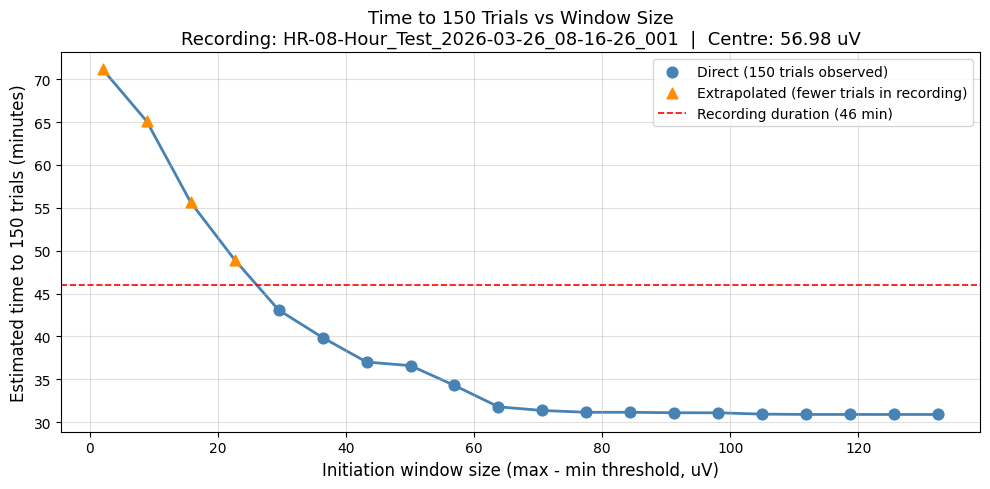

In [21]:
# Cell 9: Time to reach TARGET_TRIALS vs window size

# Guard: recompute time_to_target_min from trial rate if the run loop
# was executed before this key was added to results.
if results and "time_to_target_min" not in results[0]:
    _dur_s = float(timestamps[-1] - timestamps[0])
    for _r in results:
        _n = _r["n_trials"]
        if _n > 0:
            _r["time_to_target_min"] = TARGET_TRIALS / (_n / (_dur_s / 60.0))
        else:
            _r["time_to_target_min"] = float("nan")

times_min    = [r["time_to_target_min"] for r in results]
extrapolated = [r["n_trials"] < TARGET_TRIALS for r in results]

fig, ax = plt.subplots(figsize=(10, 5))

ws_direct = [w for w, e in zip(window_sizes, extrapolated) if not e]
t_direct  = [t for t, e in zip(times_min,   extrapolated) if not e]
ws_extrap = [w for w, e in zip(window_sizes, extrapolated) if e]
t_extrap  = [t for t, e in zip(times_min,   extrapolated) if e]

ax.plot(window_sizes, times_min, "-", color="steelblue", linewidth=2, zorder=1)
ax.scatter(ws_direct, t_direct, color="steelblue", s=60, zorder=2, label=f"Direct ({TARGET_TRIALS} trials observed)")
ax.scatter(ws_extrap, t_extrap, color="darkorange", s=60, marker="^", zorder=2, label="Extrapolated (fewer trials in recording)")
ax.axhline(recording_duration_s / 60.0, color="red", linestyle="--", linewidth=1.2, label=f"Recording duration ({recording_duration_s/60:.0f} min)")

ax.set_xlabel("Initiation window size (max - min threshold, uV)", fontsize=12)
ax.set_ylabel(f"Estimated time to {TARGET_TRIALS} trials (minutes)", fontsize=12)
ax.set_title(f"Time to {TARGET_TRIALS} Trials vs Window Size" + chr(10) + f"Recording: {directory_str}  |  Centre: {SWEEP_CENTRE:.2f} uV", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


## 7. Plot: Time to Reach 150 Trials vs Window Size

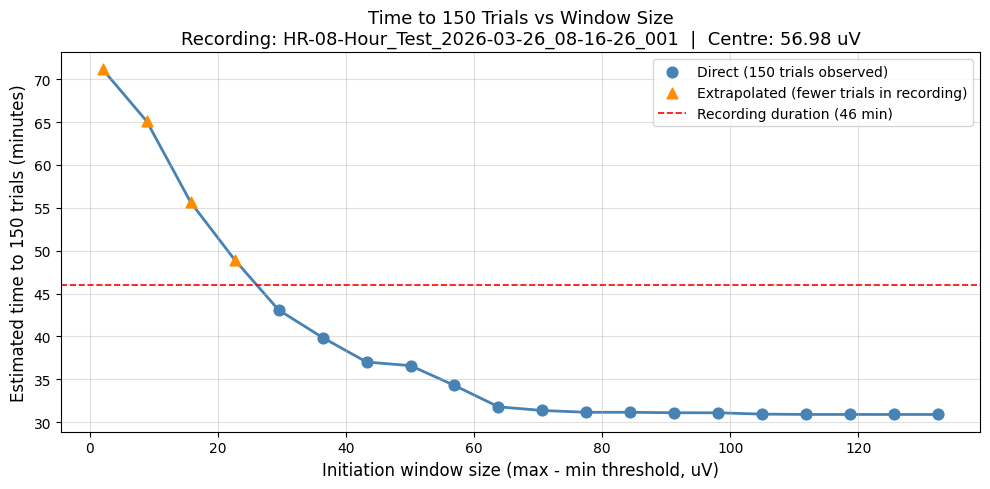

In [23]:
# Cell 9: Time to reach TARGET_TRIALS vs window size
import math

times_min = [r["time_to_target_min"] for r in results]
extrapolated = [r["n_trials"] < TARGET_TRIALS for r in results]

fig, ax = plt.subplots(figsize=(10, 5))

# Split into direct and extrapolated series for different markers
ws_direct = [w for w, e in zip(window_sizes, extrapolated) if not e]
t_direct  = [t for t, e in zip(times_min,   extrapolated) if not e]
ws_extrap = [w for w, e in zip(window_sizes, extrapolated) if e]
t_extrap  = [t for t, e in zip(times_min,   extrapolated) if e]

ax.plot(window_sizes, times_min, "-", color="steelblue", linewidth=2, zorder=1)
ax.scatter(ws_direct, t_direct, color="steelblue", s=60, zorder=2, label=f"Direct ({TARGET_TRIALS} trials observed)")
ax.scatter(ws_extrap, t_extrap, color="darkorange", s=60, marker="^", zorder=2, label="Extrapolated (fewer trials in recording)")
ax.axhline(recording_duration_s / 60.0, color="red", linestyle="--", linewidth=1.2, label=f"Recording duration ({recording_duration_s/60:.0f} min)")

ax.set_xlabel("Initiation window size (max - min threshold, uV)", fontsize=12)
ax.set_ylabel(f"Estimated time to {TARGET_TRIALS} trials (minutes)", fontsize=12)
ax.set_title(f"Time to {TARGET_TRIALS} Trials vs Window Size" + chr(10) + f"Recording: {directory_str}  |  Centre: {SWEEP_CENTRE:.2f} uV", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


## 8. Plot: Trials per Hour vs Window Size

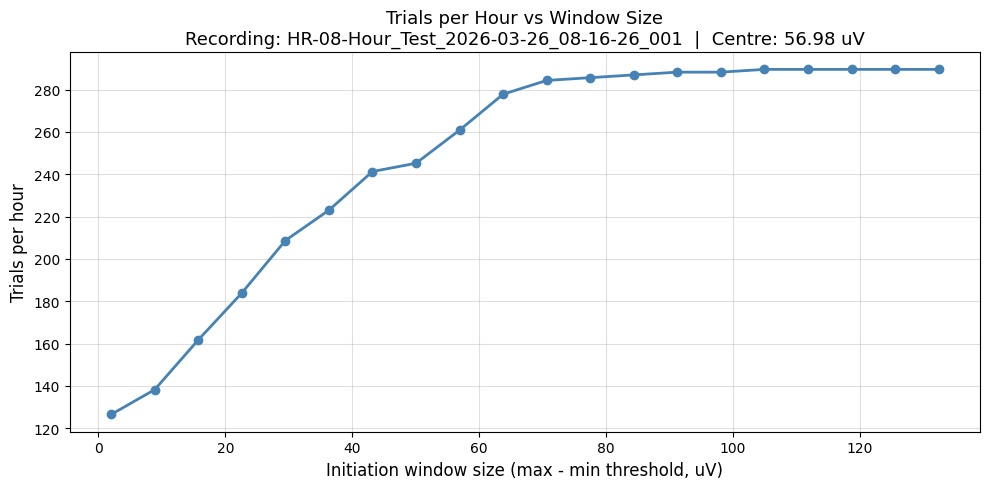

Recording duration: 0.77 hours
   Window (uV)     Trials/hr
------------------------------
          2.00         126.5
          8.87         138.2
         15.73         161.7
         22.60         183.9
         29.46         208.7
         36.33         223.0
         43.20         241.3
         50.06         245.2
         56.93         260.8
         63.80         277.8
         70.66         284.3
         77.53         285.6
         84.39         286.9
         91.26         288.2
         98.13         288.2
        104.99         289.5
        111.86         289.5
        118.73         289.5
        125.59         289.5
        132.46         289.5


In [24]:
# Cell 10: Trials per hour vs window size
recording_hours = recording_duration_s / 3600.0
trials_per_hour = [r["n_trials"] / recording_hours for r in results]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(window_sizes, trials_per_hour, "o-", color="steelblue", linewidth=2, markersize=6)

ax.set_xlabel("Initiation window size (max - min threshold, uV)", fontsize=12)
ax.set_ylabel("Trials per hour", fontsize=12)
ax.set_title("Trials per Hour vs Window Size" + chr(10) + f"Recording: {directory_str}  |  Centre: {SWEEP_CENTRE:.2f} uV", fontsize=13)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Recording duration: {recording_hours:.2f} hours")
col_w = "Window (uV)"
col_t = "Trials/hr"
print(f"{col_w:>14}  {col_t:>12}")
print("-" * 30)
for r, tph in zip(results, trials_per_hour):
    ws = r["window_size"]
    print(f"{ws:>14.2f}  {tph:>12.1f}")
